# Figure 3: Copy # Correction

**Goal:**

Present the copy number correction story: Copy number correction amends differential replication effects on gene expression and chromatin.


In [404]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [597]:
from src.Figure3_Copy_Correction import Figure3CopyCorrection

figures = Figure3CopyCorrection()

In [ ]:
# Replication profile estimation

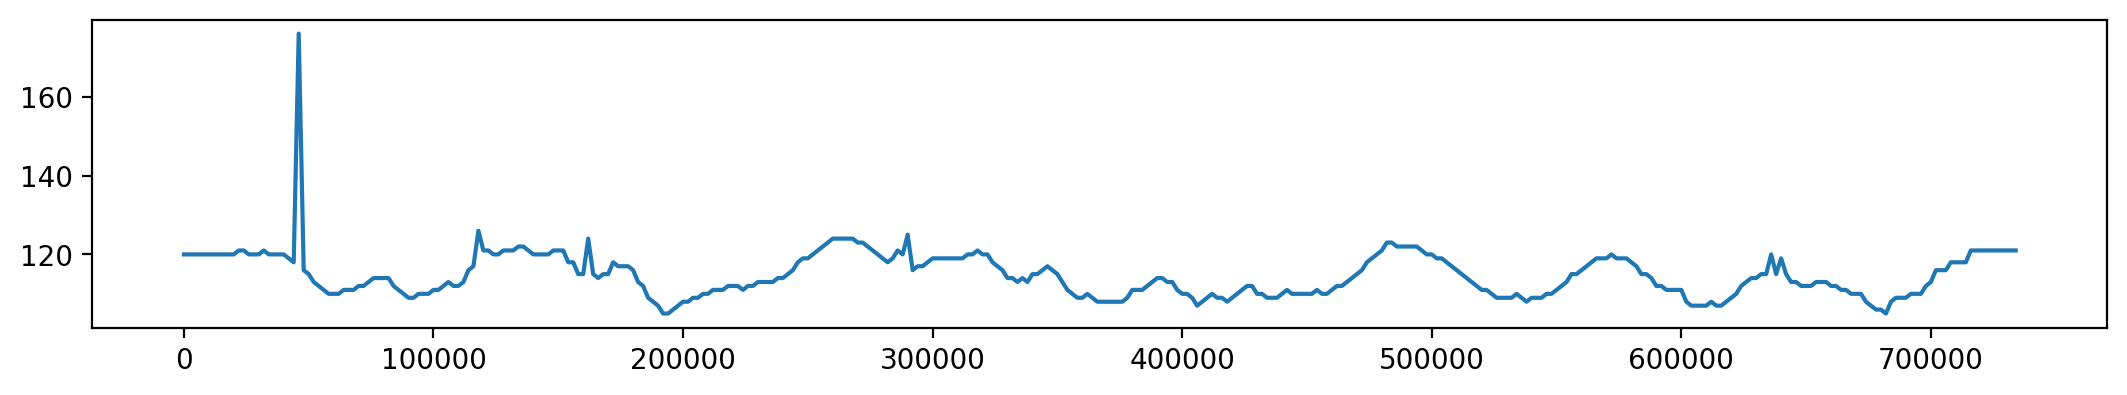

In [697]:
# Depiction of the chromosome 10 replication timing profile computed from the MNase-seq

chrom_replication_profile = pd.read_csv('data/replication_timing/yl_2019/chrom_replication_timing_shared.csv')
chrom_replication_profile = chrom_replication_profile.set_index(['chr', 'start'])

plt.figure(figsize=(13, 2))
plt.plot(chrom_replication_profile.loc[10])

# Copy number correction procedure....



In [696]:
from src.stepwise_replication_solver import load_gene_replication_profile
load_gene_replication_profile('shared').loc['YJL205C']

replication_time        45.6102
replication_H_index    176.0000
Name: YJL205C, dtype: float64

# Chromatin Analysis

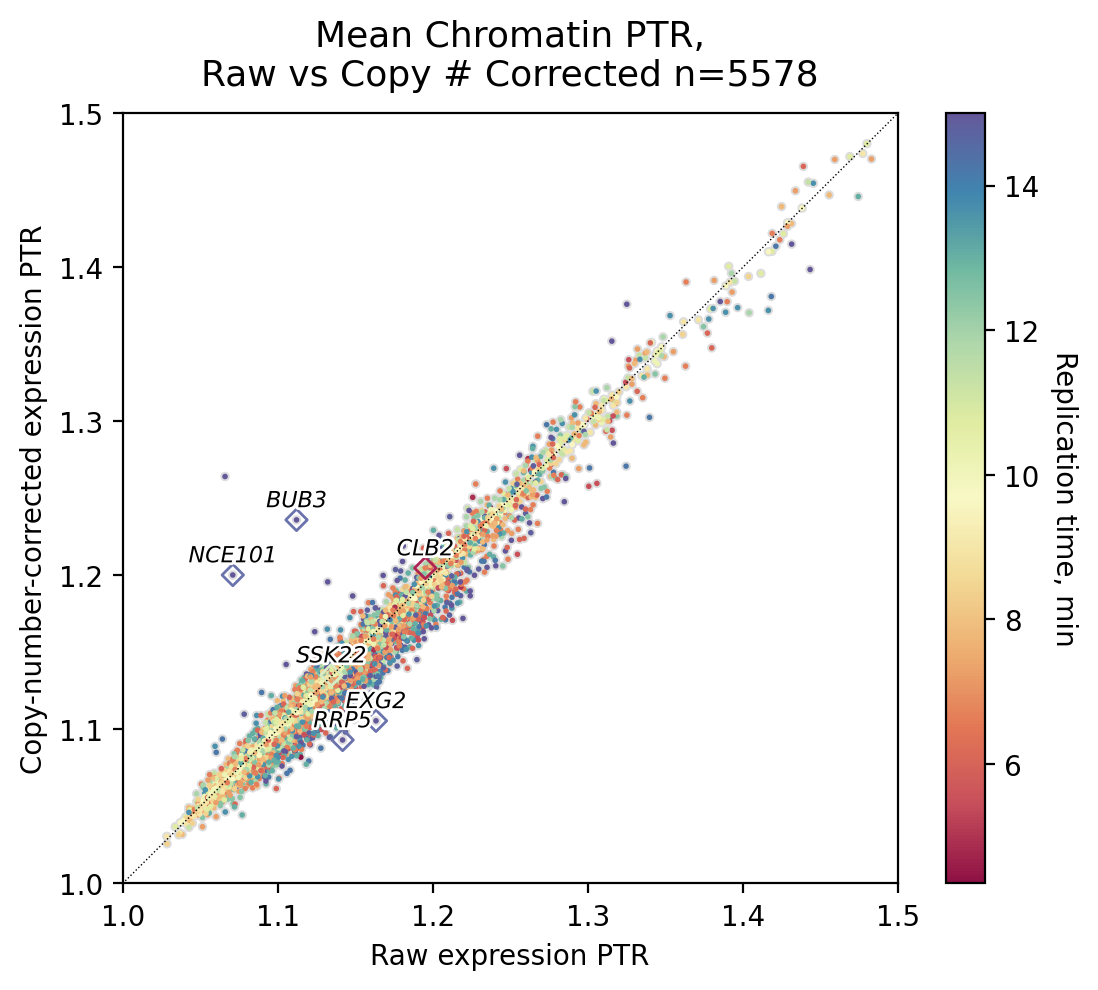

In [674]:
from src.figure_configs import save_figure_for_paper

figures.plot_chrom_ptr_correction()
save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_PTR.png')

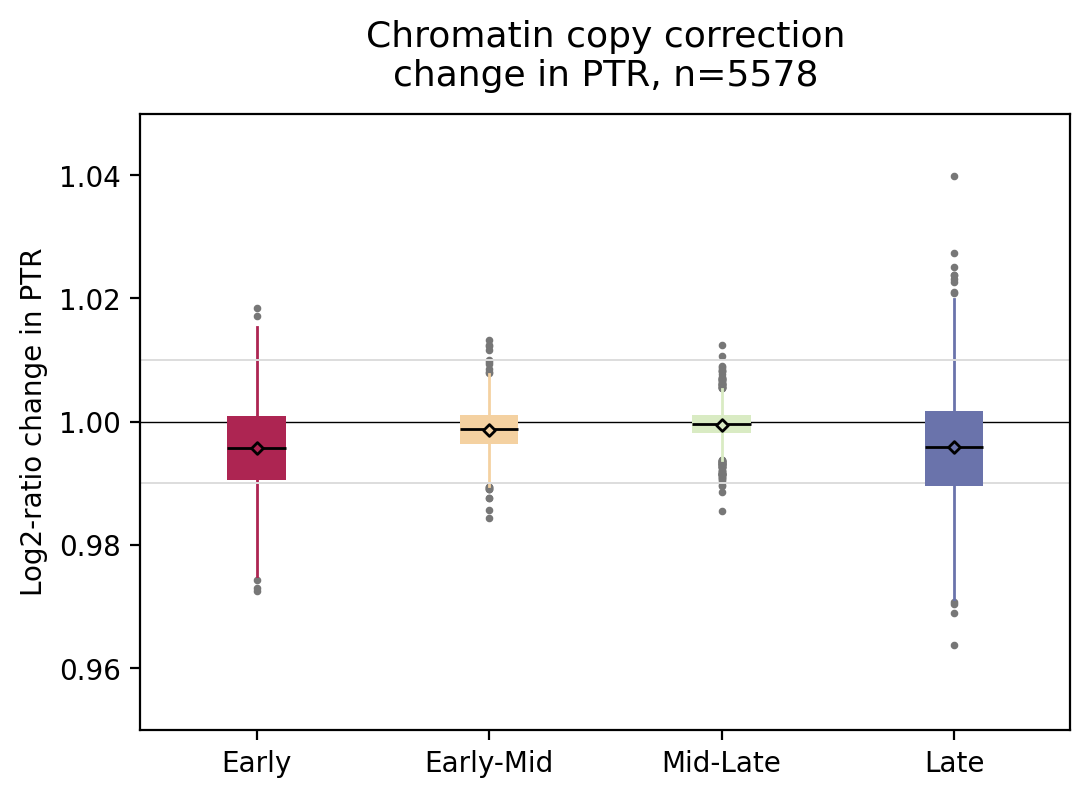

In [675]:
figures.plot_chrom_ptr_rep_quantiles()
save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_Box.png')

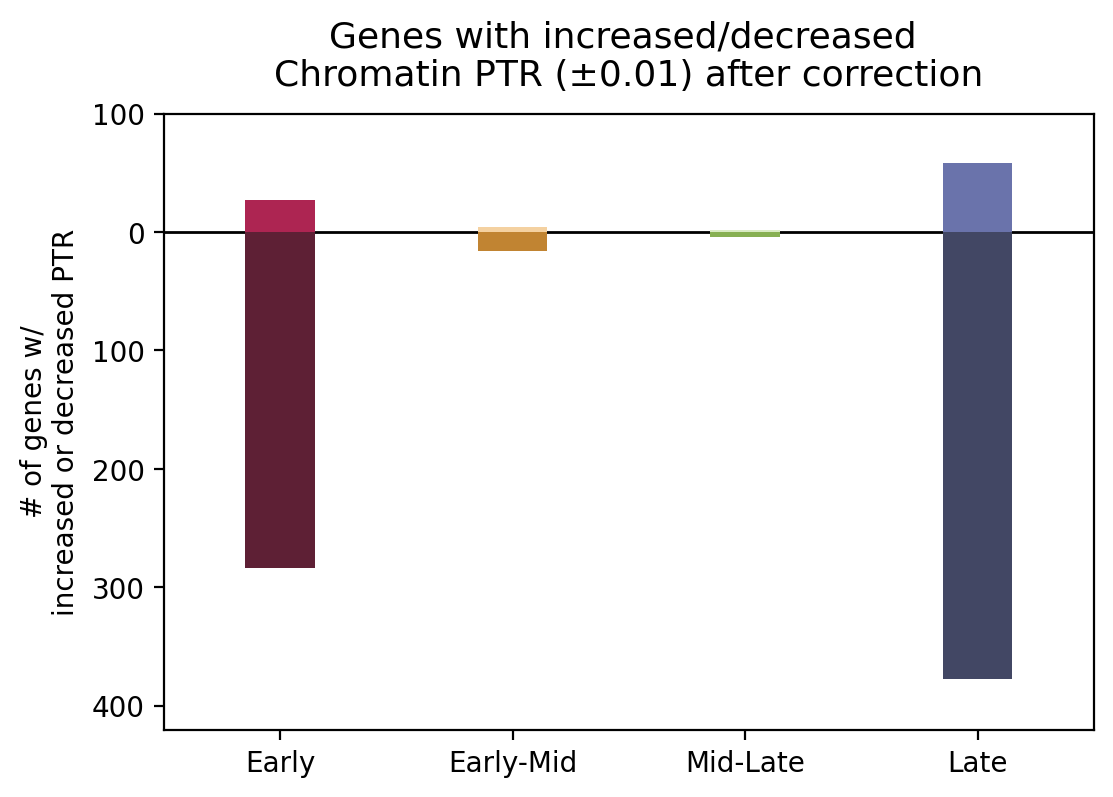

In [676]:
figures.plot_chrom_ptr_counts()
save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_Bar.png')

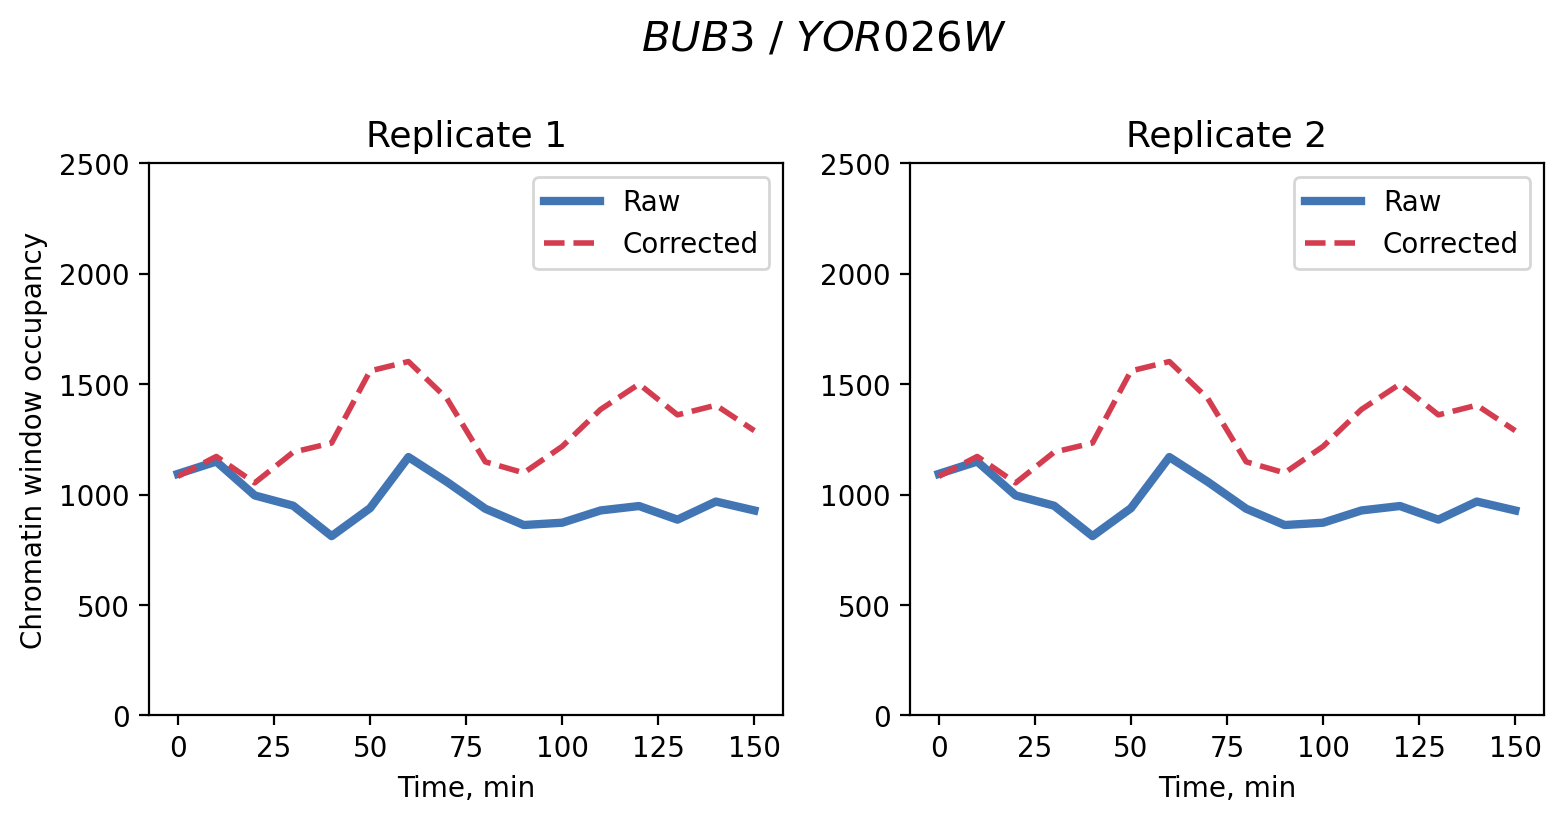

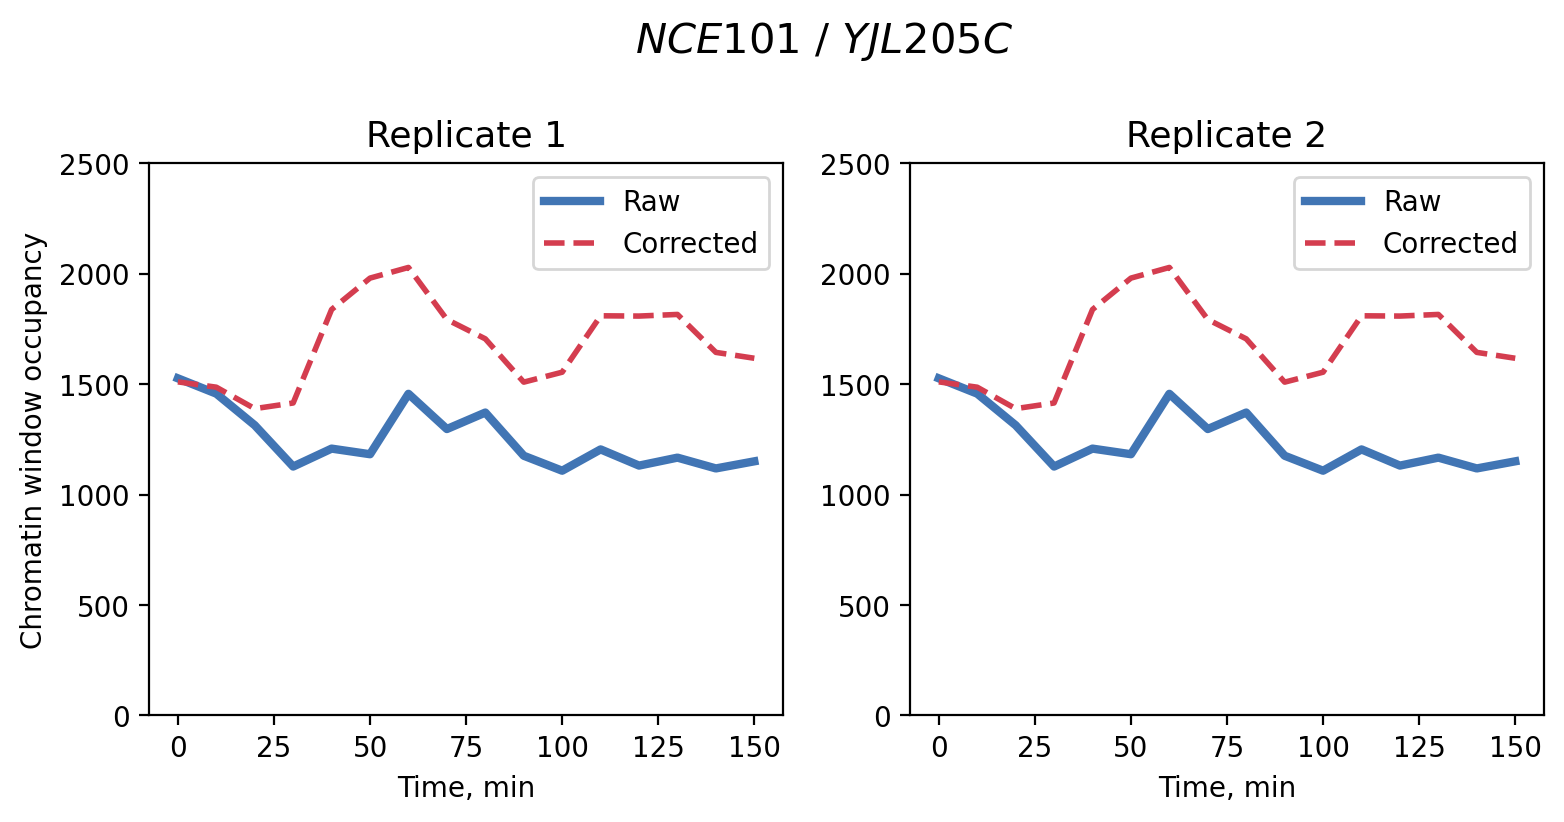

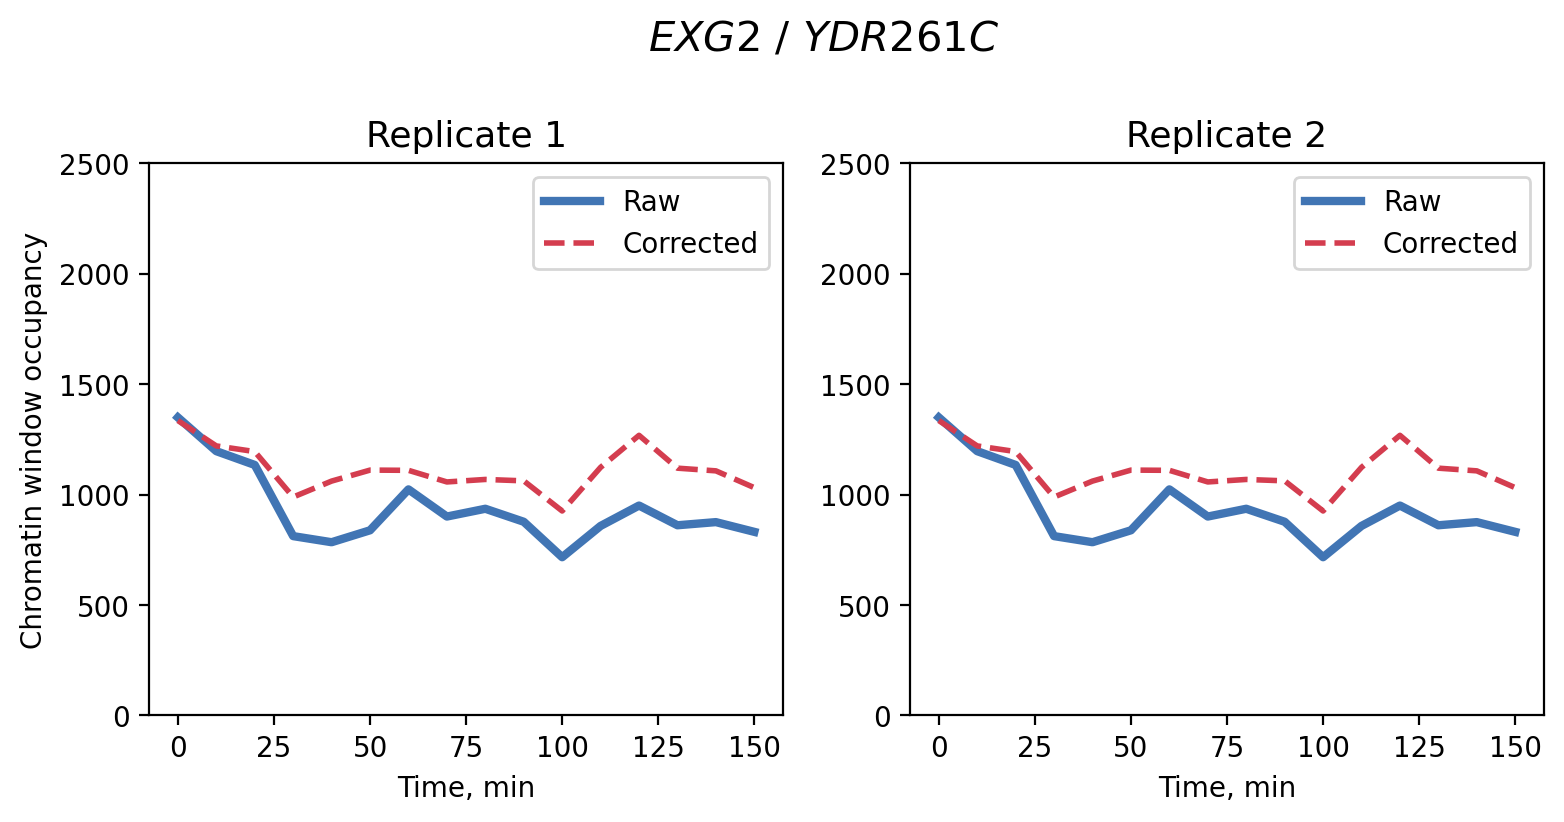

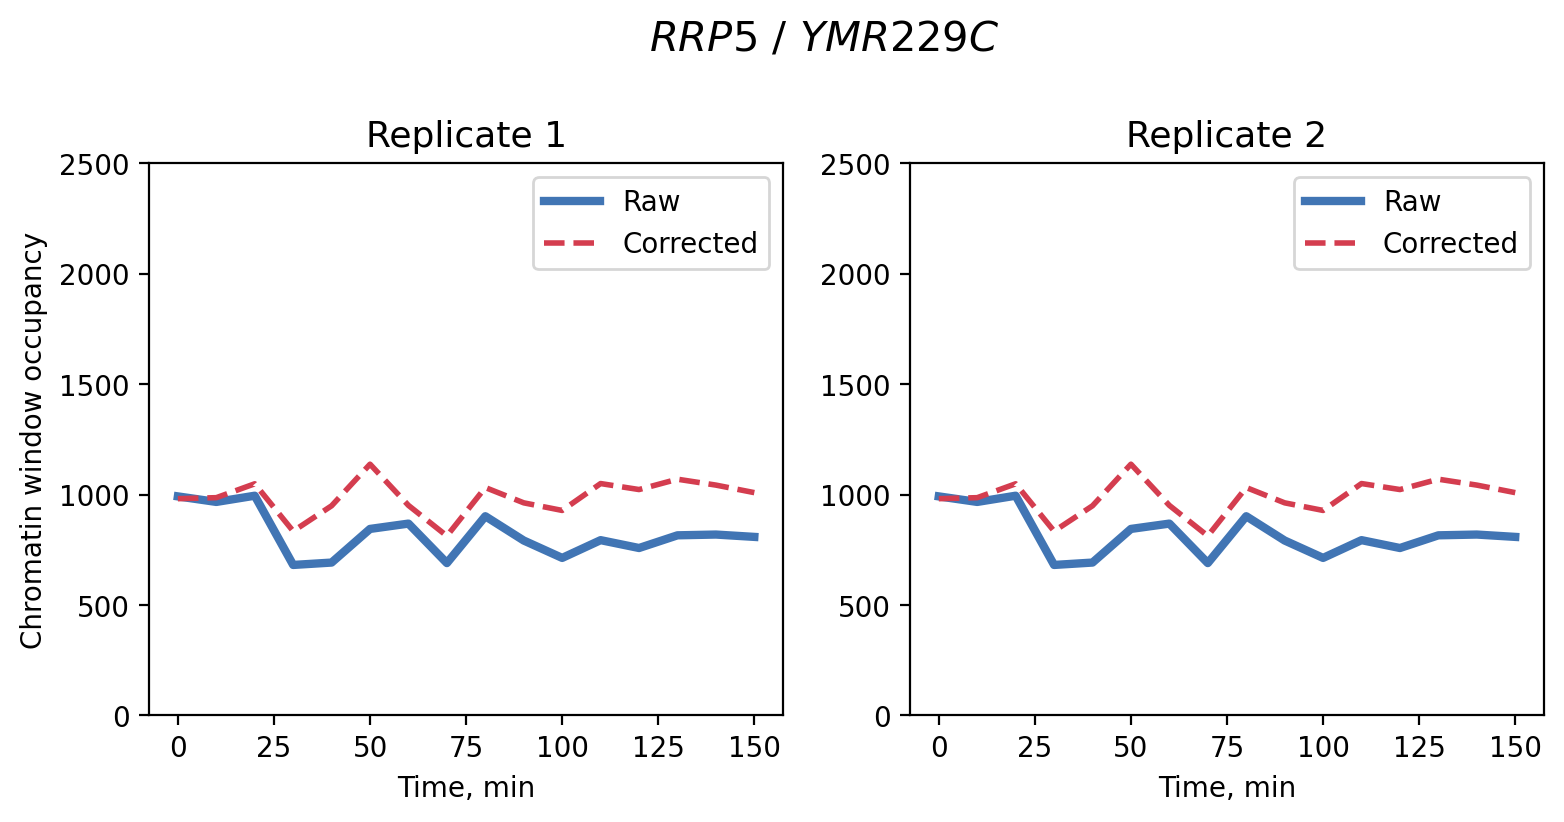

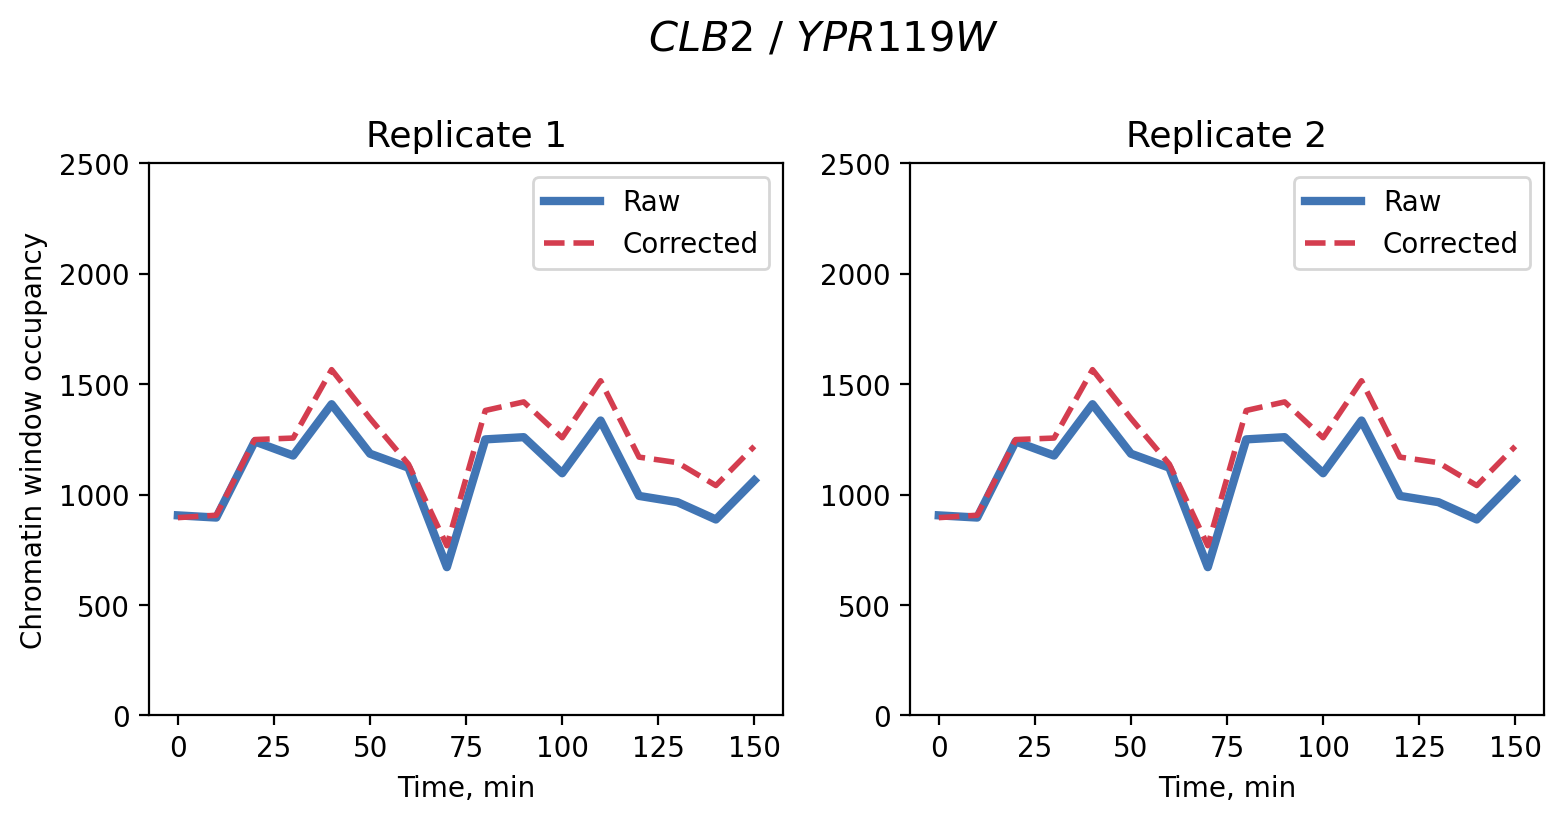

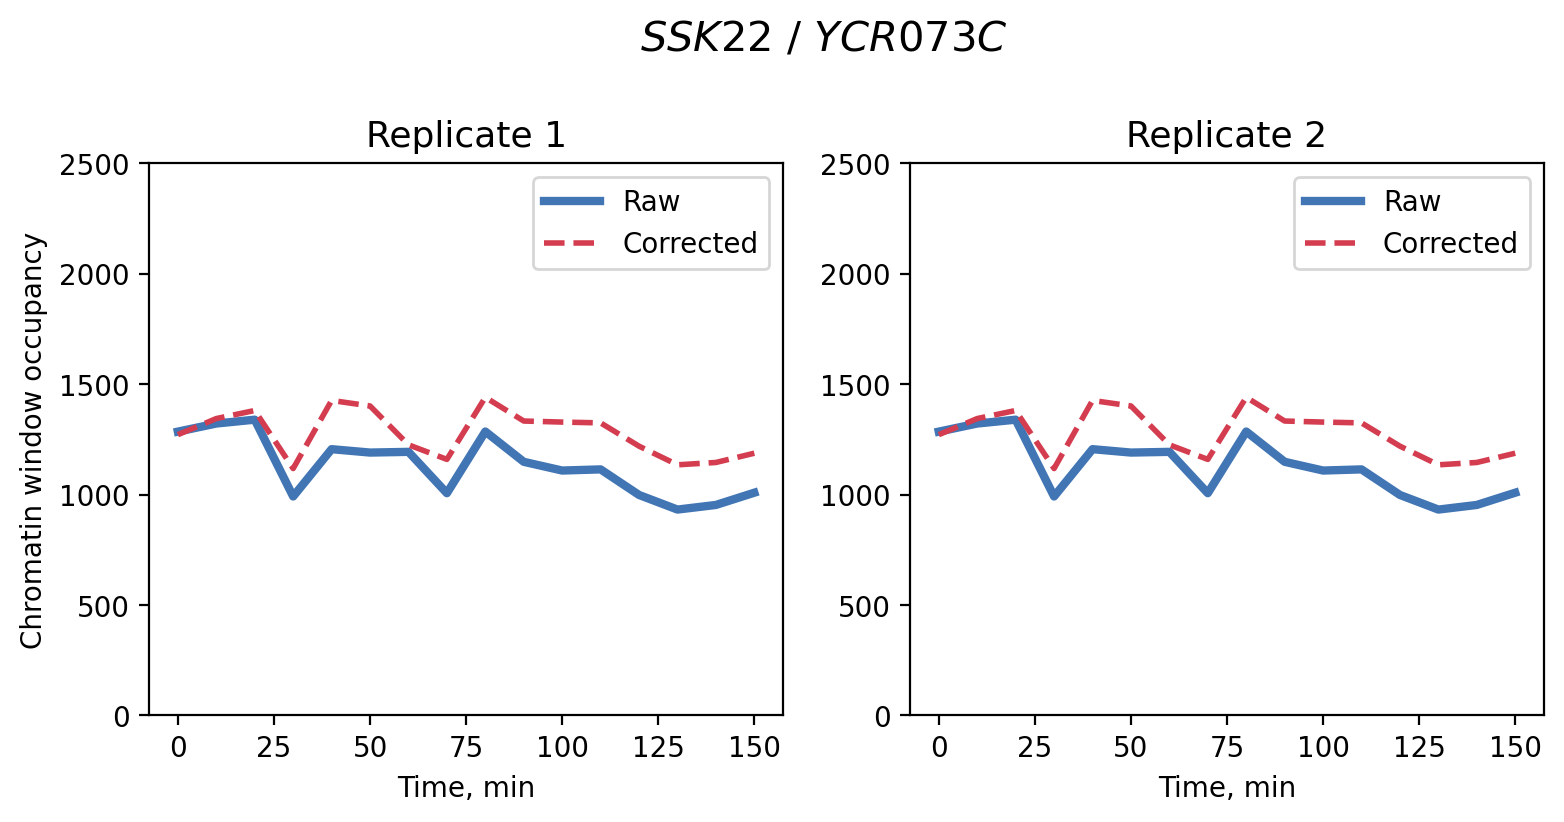

In [679]:
figures.plot_chrom_examples(save_dir='output/figures/Copy_Correction/')

In [ ]:
def print_genes_for_go(sel_genes, genes):
    selected_orfs = sel_genes.index
    gene_names = genes[['gene']].loc[selected_orfs].gene
    for g in gene_names:
        print(g)


In [659]:
cycling_chrom_genes = figures.mean_chrom_ptrs.sort_values('unnormalized_raw_ptr').tail(200)
print_genes_for_go(cycling_chrom_genes, genes)

# These genes appear to be cycling in the chromatin regardless of correction
# GO reveals that a handful of these genes are enriched as glycolytic process genes
# 7 or so, so not too prominent. And these are genes that are enriched by overall window
# occupancy...


YHR007C-A
CSH1
YNL190W
BRN1
YGL117W
PGK1
RNQ1
PET122
YKL133C
PRE5
NAT3
YIL060W
TAL1
HTA1
YDR524C-B
MPS3
SAC7
HHT1
SDS24
WSC4
SPC25
YPD1
FUS2
YAL018C
TOM7
MET4
LAA1
FUS3
ARL1
TAD2
CWC2
CRH1
RPL2A
MRPL15
GRX6
PAM1
POM34
YGL138C
XYL2
TYW1
SNF11
YDR246W-A
YNL146W
HSP60
RPL22A
YBR196C-B
YCR099C
HUA1
PFK1
CTH1
FBA1
GUT2
TUB4
VTC1
HOS3
MDM32
YMR030W-A
SWM1
PMT2
RIB3
LIP5
TYE7
HLR1
PUT4
PEX2
SEC23
FLC2
TIM12
YOL029C
HMX1
SED5
GCN4
RPL41B
EAR1
RPL11B
GIR2
YMR001C-A
VPS24
BIK1
BAS1
YCR100C
YHB1
CAN1
PNO1
CRM1
RPS13
BUR2
YKL023W
ASG1
PHM8
NSE1
BIO5
UBS1
YOL036W
YBR196C-A
NOG2
CDC5
MFA2
YNL122C
IMP2'
COX7
MRPS16
CHS1
KAR2
UTR5
SSA2
AGA1
AUA1
ILV6
YMR317W
SSZ1
CET1
YNL277W-A
LST8
XBP1
BFR1
YCH1
YER064C
CHO2
ZEO1
RPS21A
FIG2
NAG1
ERG11
YER138W-A
TPI1
YLR225C
CCW14
STB6
DIP2
YLR046C
MCA1
PMA1
PGI1
TGL4
SLH1
YKR041W
UME6
QCR8
TLG2
SGF11
HAC1
YGR161W-C
YCL042W
RPL3
CDC19
RRD1
AAD10
FIG1
TRK2
HHF1
CHL4
MBF1
PET9
ESC8
CNL1
SMI1
YGL007C-A
SRC1
PDI1
CHS2
PBP4
PRM1
YGL235W
SSK1
YAH1
ASG7
BDF2
YAL064C-A
MUP1

# Gene Expression Analysis

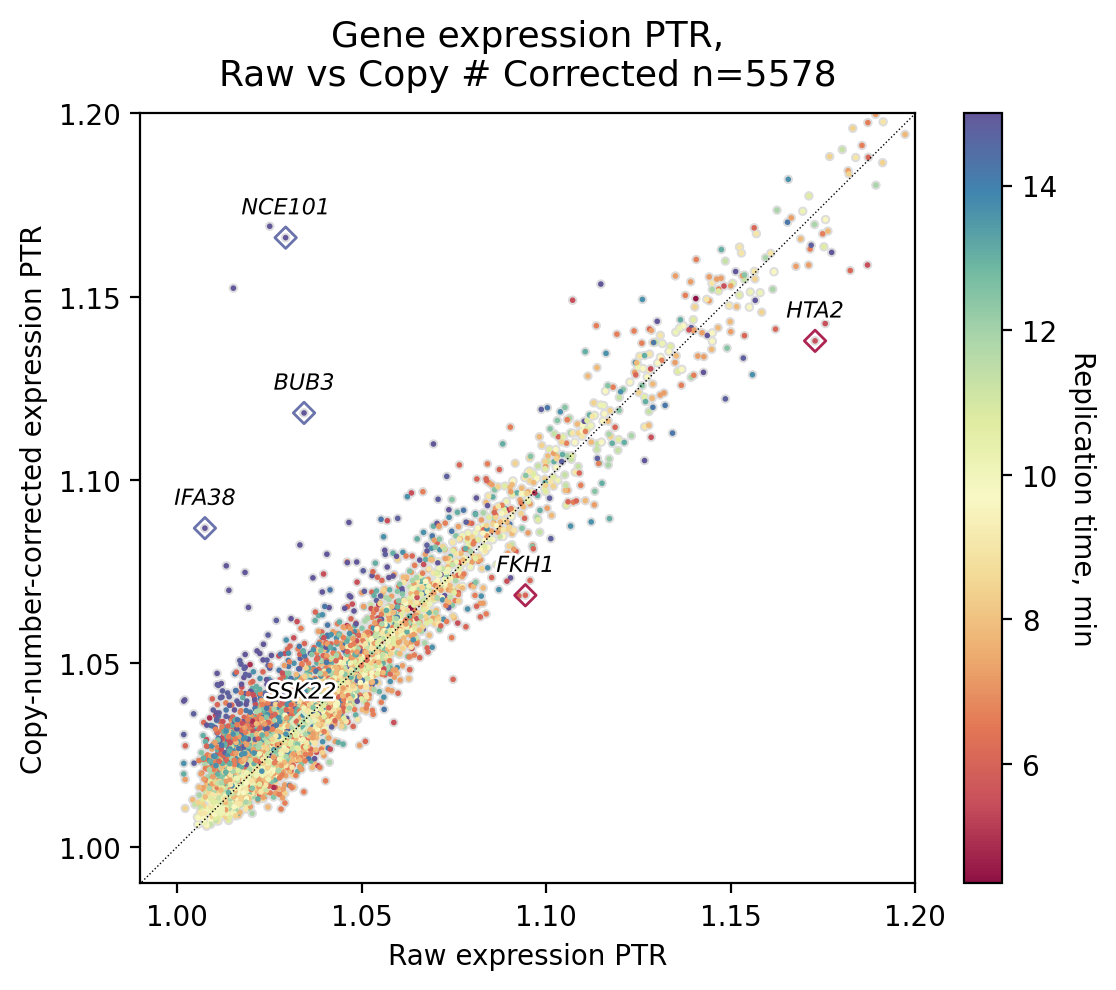

In [665]:
figures.plot_ge_ptr_correction()

save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Expression_PTR.png')

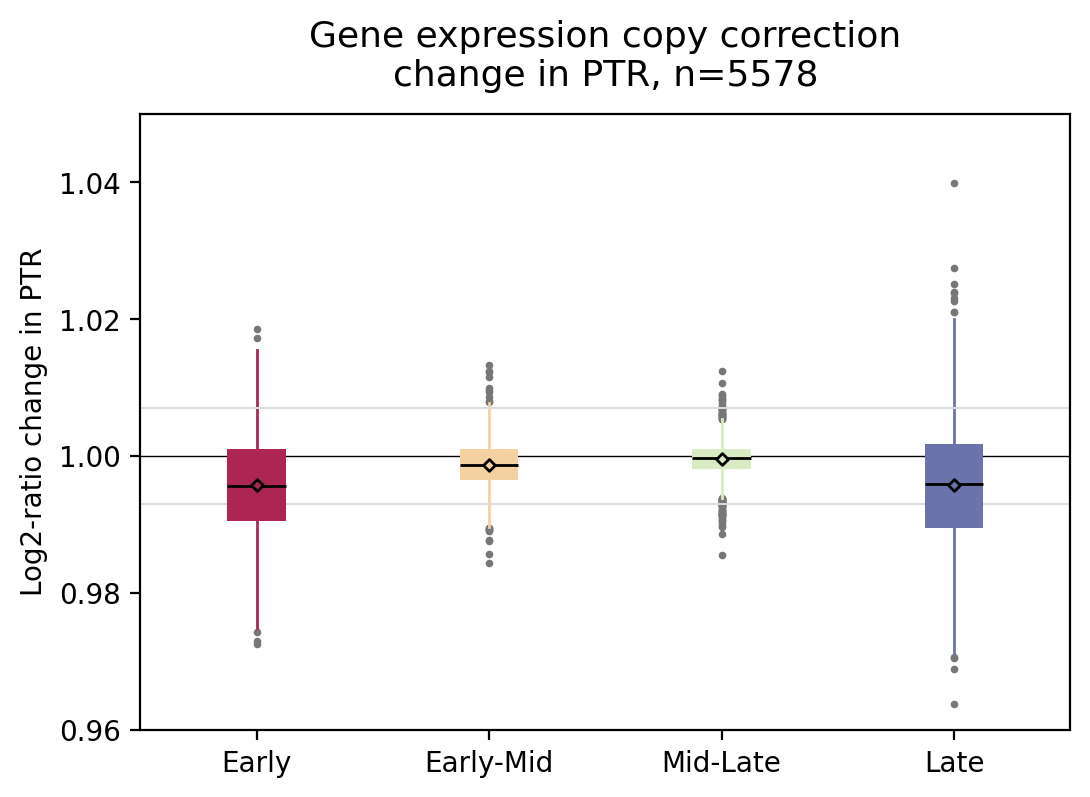

In [671]:
figures.plot_ge_ptr_rep_quantiles()
save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Expression_PTR_Box.png')

In [635]:
decreasing_ptr_genes = figures.mean_ge_ptrs[figures.mean_ge_ptrs.log_ratio < 1 - figures.delta_ge]
selected_orfs = decreasing_ptr_genes.index
gene_names = genes[['gene']].loc[selected_orfs].gene

for g in gene_names:
    print(g)
    
# Gene ontology results for gene PTRs that decrease yields many cell cycle genes.
# is this to be expected? These are genes with high PTR (are cell cycling) and
# decrease past the threshold to a lower PTR value. What is noteworthy about this?
#
# Perhaps if the same can be said about the chromatin.
#
# Nothing interesting comes up for genes with increased PTR.
#

SEO1
KIN3
RRN6
ALK2
UTP20
HTA2
HTB2
HHF1
AAC3
PHO5
TFC1
SHE3
IRA1
ICS2
AMN1
GRX1
LSB5
HBN1
BUD3
RER1
YCL001W-A
YIH1
YCR090C
GIT1
YDL186W
ENT1
NSE4
POL3
NUR1
SLX5
DAD1
PST2
MAK21
ALT2
MRPL1
HST4
UME6
MFB1
YDR222W
HTB1
HTA1
SIR4
HSP78
SPC110
YHP1
DIG2
IZH1
AVT2
ANP1
SNU13
PMI40
PRP22
SWI4
GLO3
FTR1
ADK2
YFL052W
YFL051C
ALR2
GYP8
CDC14
YMR31
HXK1
ZRT1
RMR1
MCM6
TOS3
VPS45
RIM8
SCW11
PDR1
ERG4
COX18
ROM1
DAM1
COG2
NSR1
BUB1
BNS1
PHB2
YHB1
SPO11
RRF1
YHR054C
HXT5
GEP4
SPC97
STB5
MLP2
FKH1
POG1
RPI1
SNL1
BET1
FAR1
YAK1
YJL118W
ALY2
TAX4
PRY1
LOH1
MAD3
AVT1
YJR030C
BFA1
IML1
PMT4
MRPL38
YKL071W
ASK1
LAC1
AUR1
TOF2
SPC34
GAP1
YKR041W
UIP5
FMP46
GPT2
YLL032C
GPI13
CMS1
STU2
RPL22A
MDN1
YLR211C
FRE1
PIG1
MCM5
CTS1
CDA2
YLR342W-A
GAS2
YLR413W
PGA3
TSL1
TUB1
SMA2
ORC1
TEM1
YMR001C-A
YMR031C
JLP2
YMR144W
SGS1
YMR196W
SAP30
RRN9
PGM3
ADH2
YMR315W-A
DIA1
PEX6
EGT2
YNL195C
NOP13
APC1
BNI5
FKH2
AQR1
YIP3
HHT2
HHF2
PBI2
NRM1
TRM13
PAP2
MSB4
ATG34
BRX1
UTP23
YOR008C-A
HMS1
SGO1
WHI5
CDC31
DSE3
YOR268C
RR

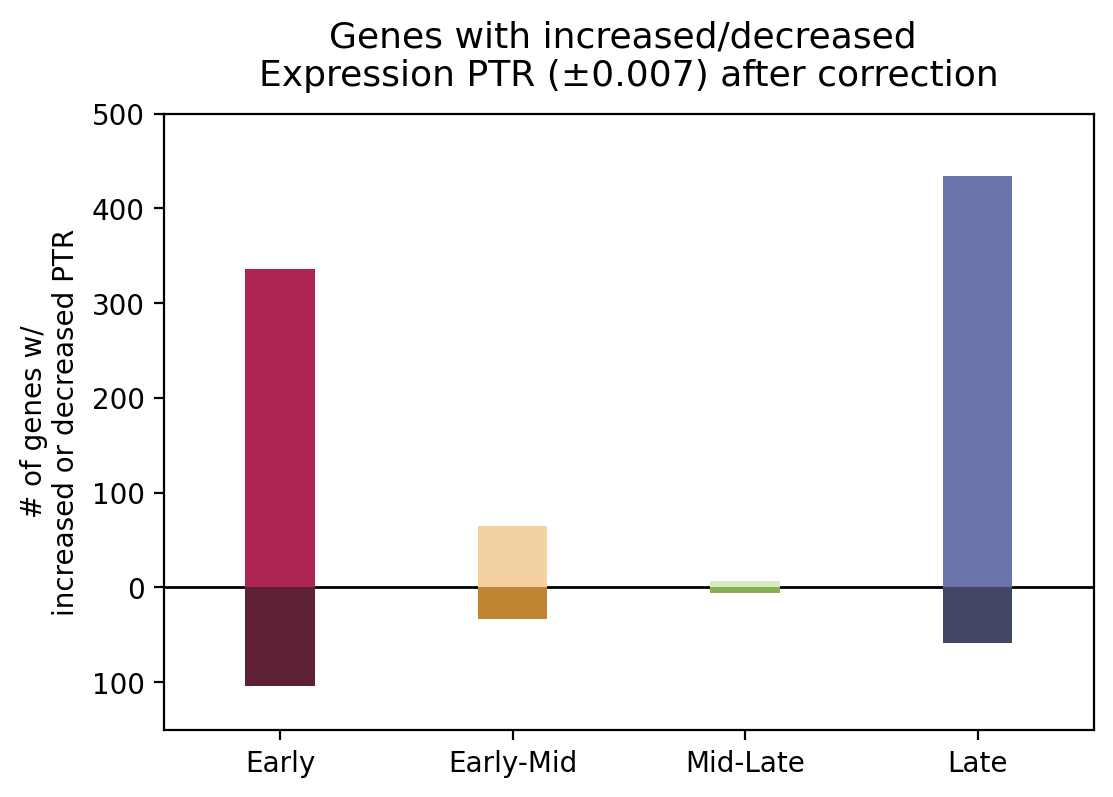

In [670]:
figures.plot_gene_expression_ptr_counts()

save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Expression_PTR_Bar.png')

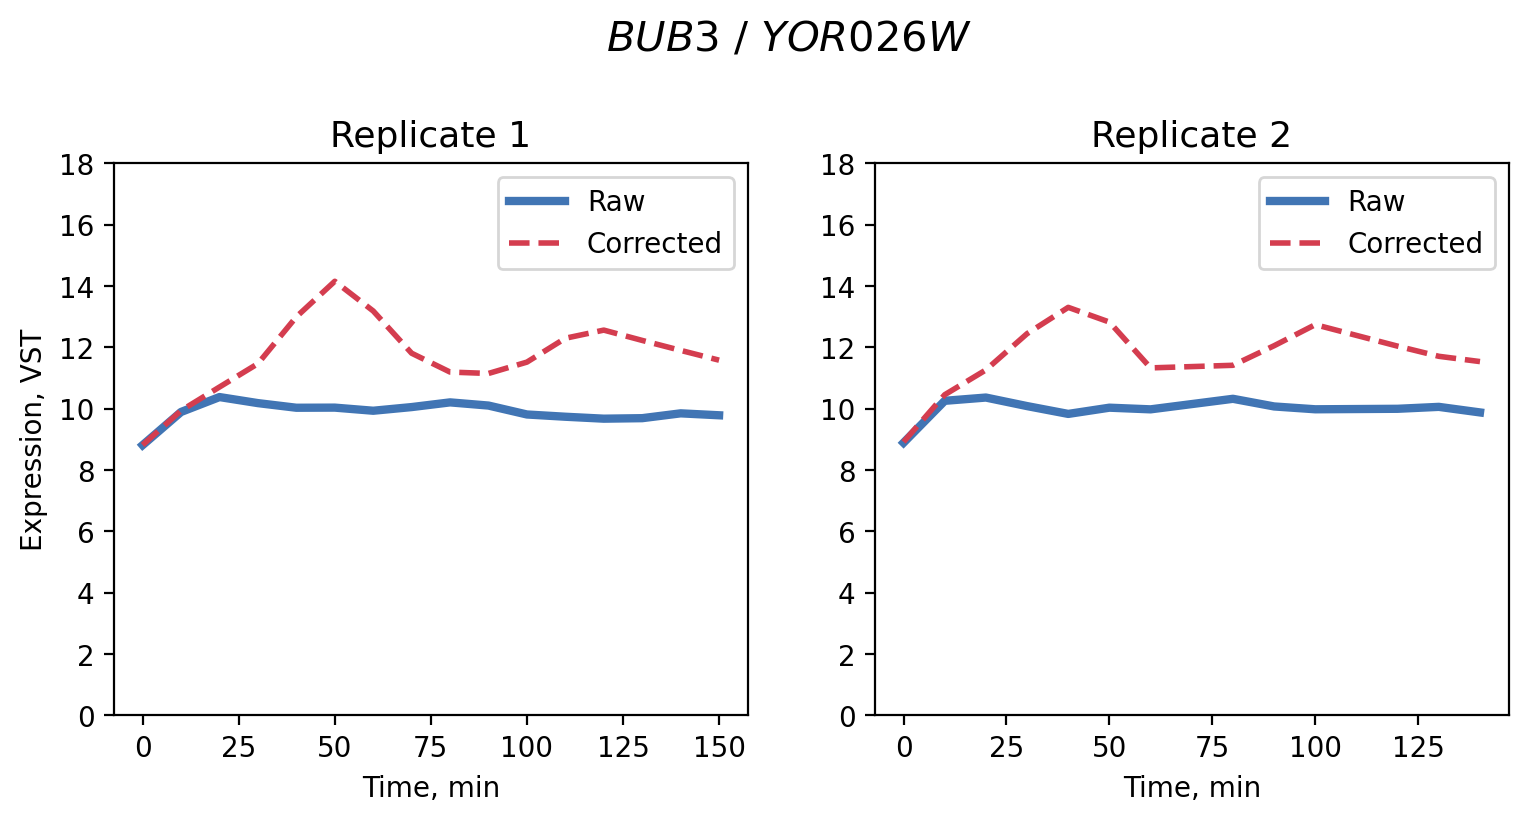

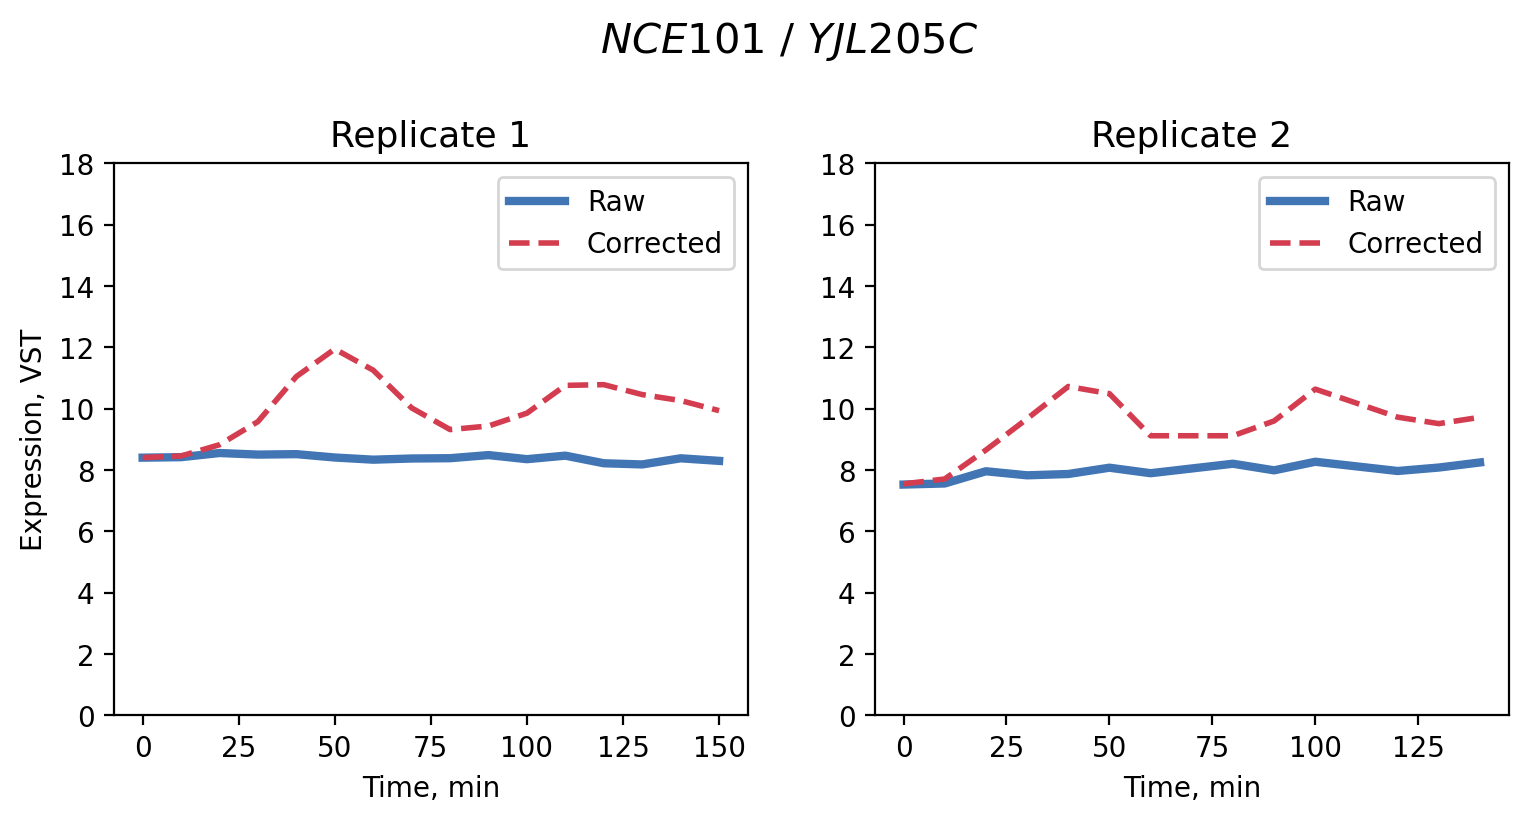

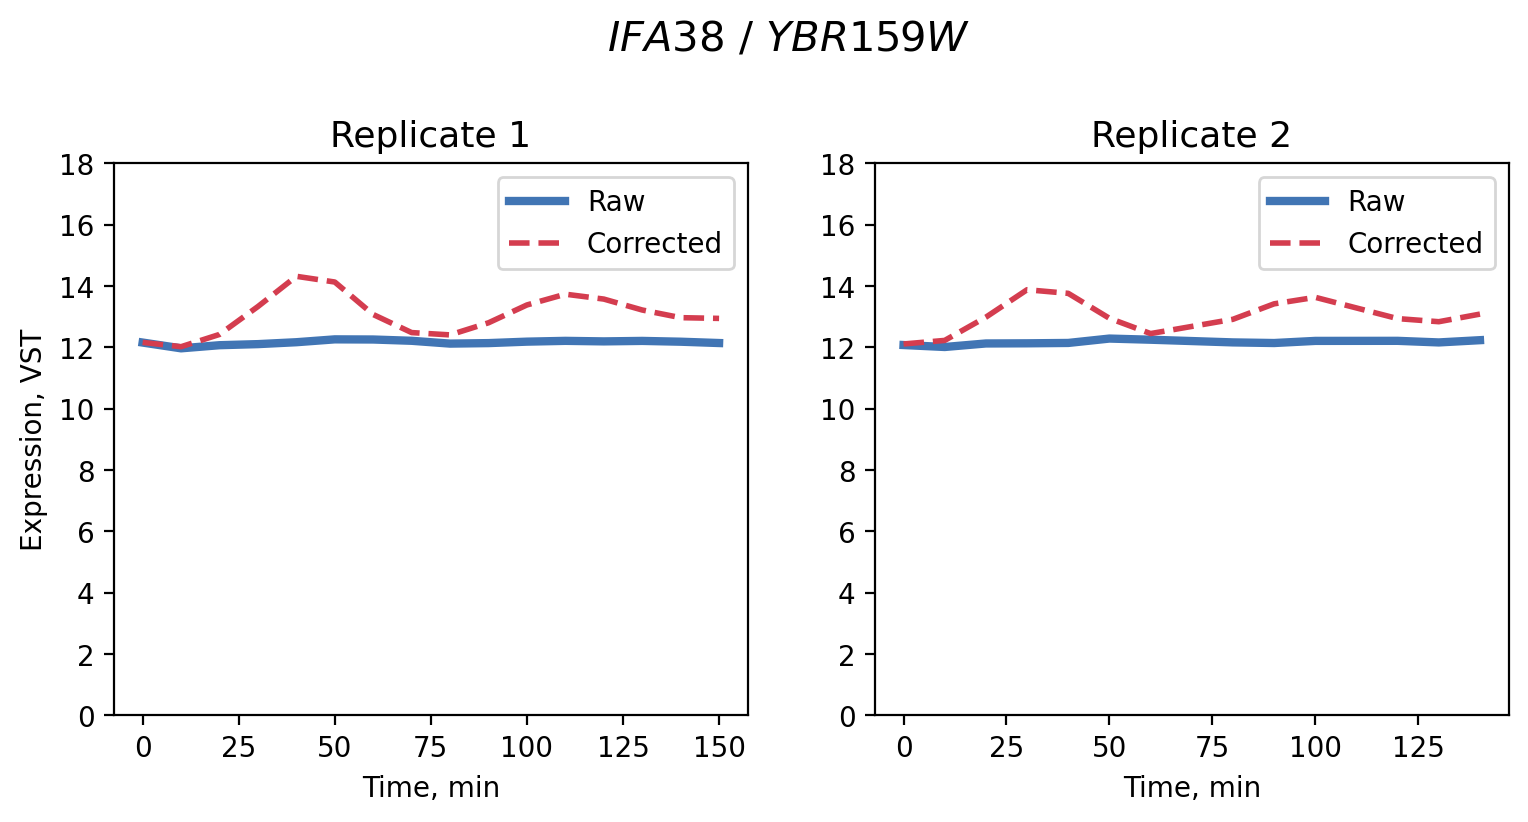

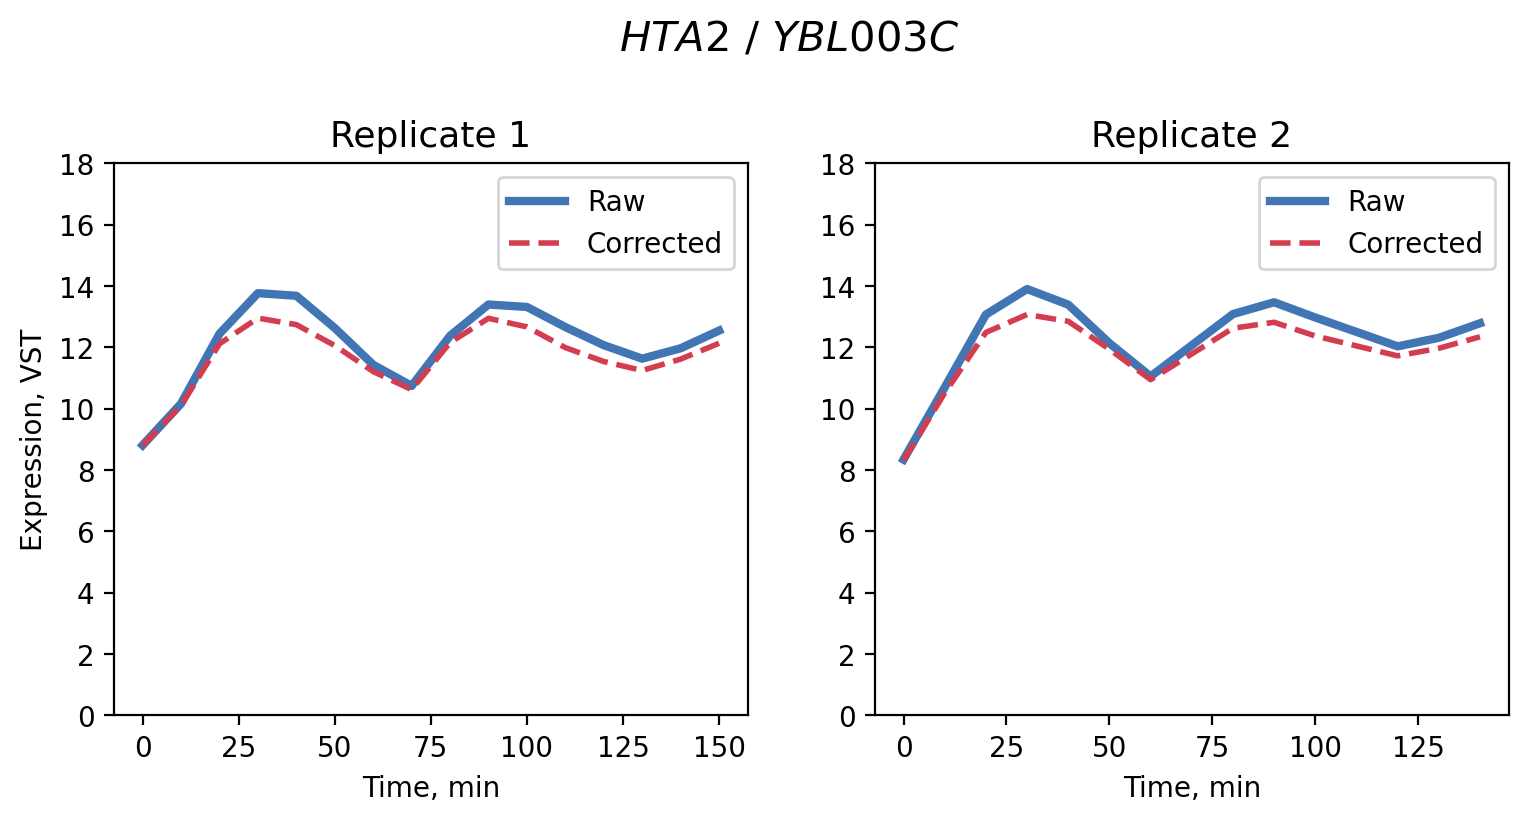

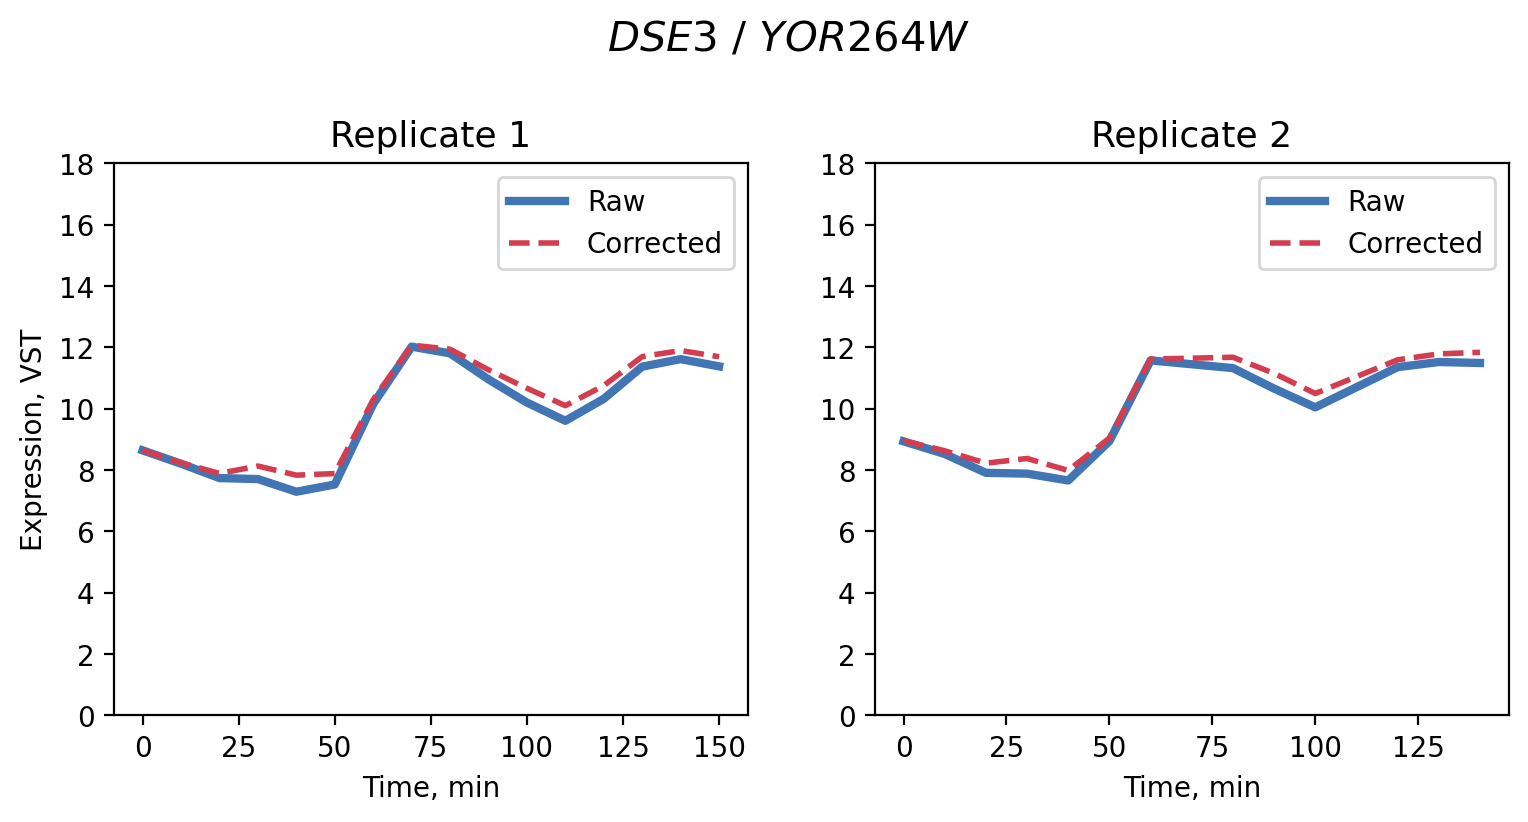

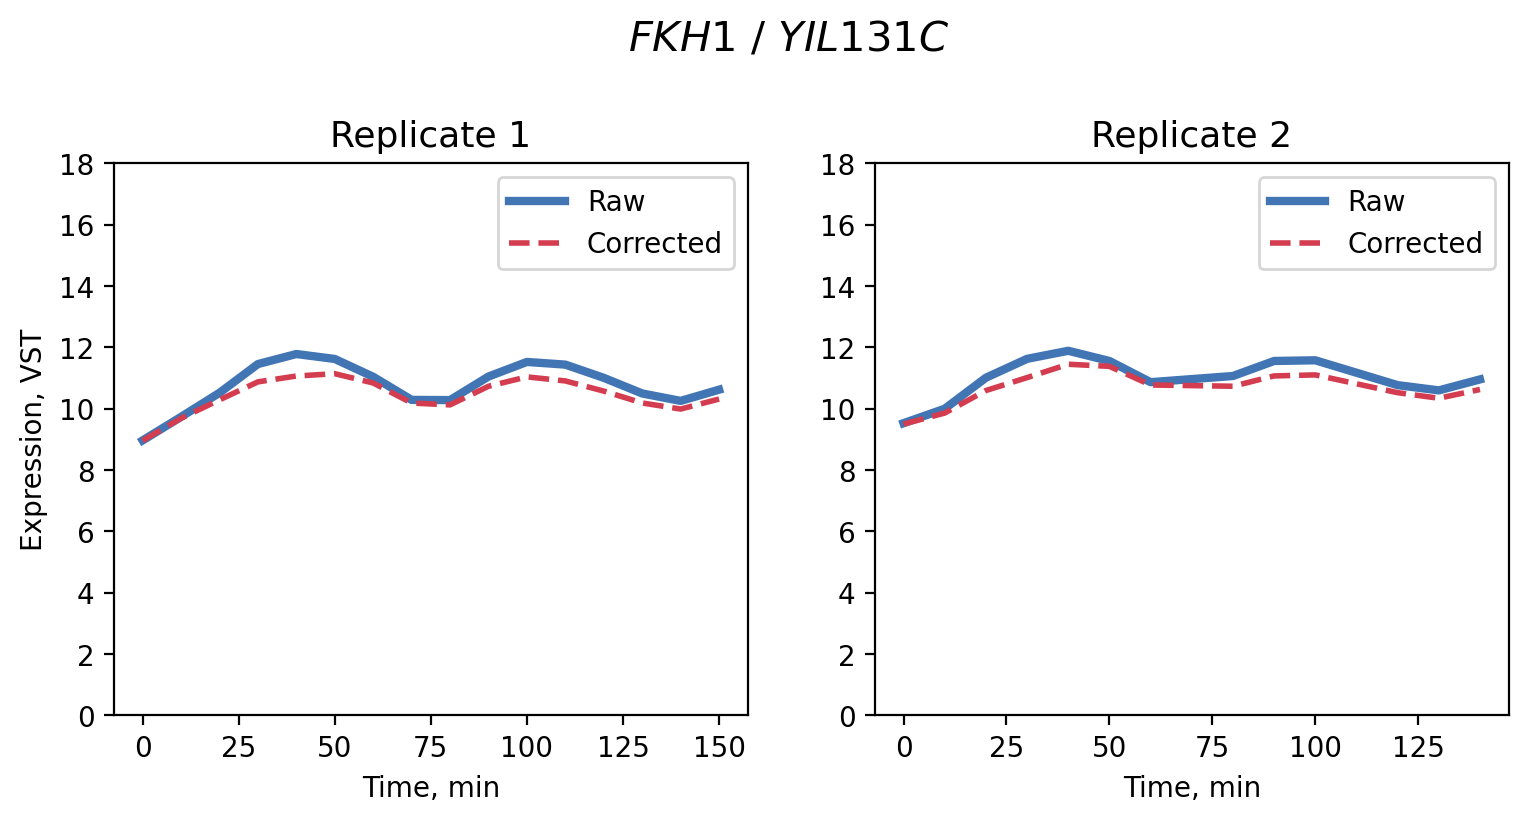

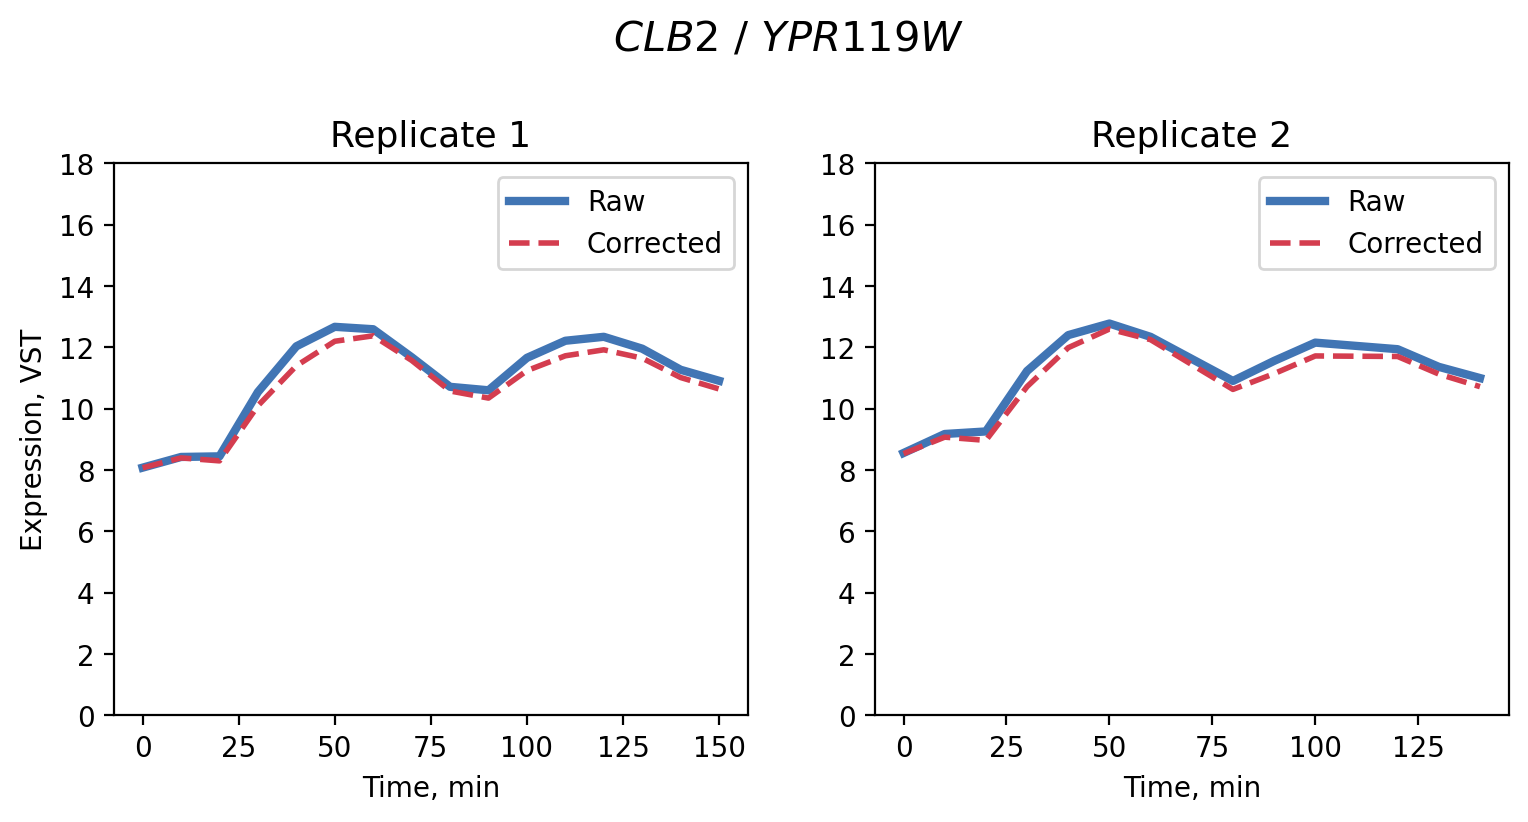

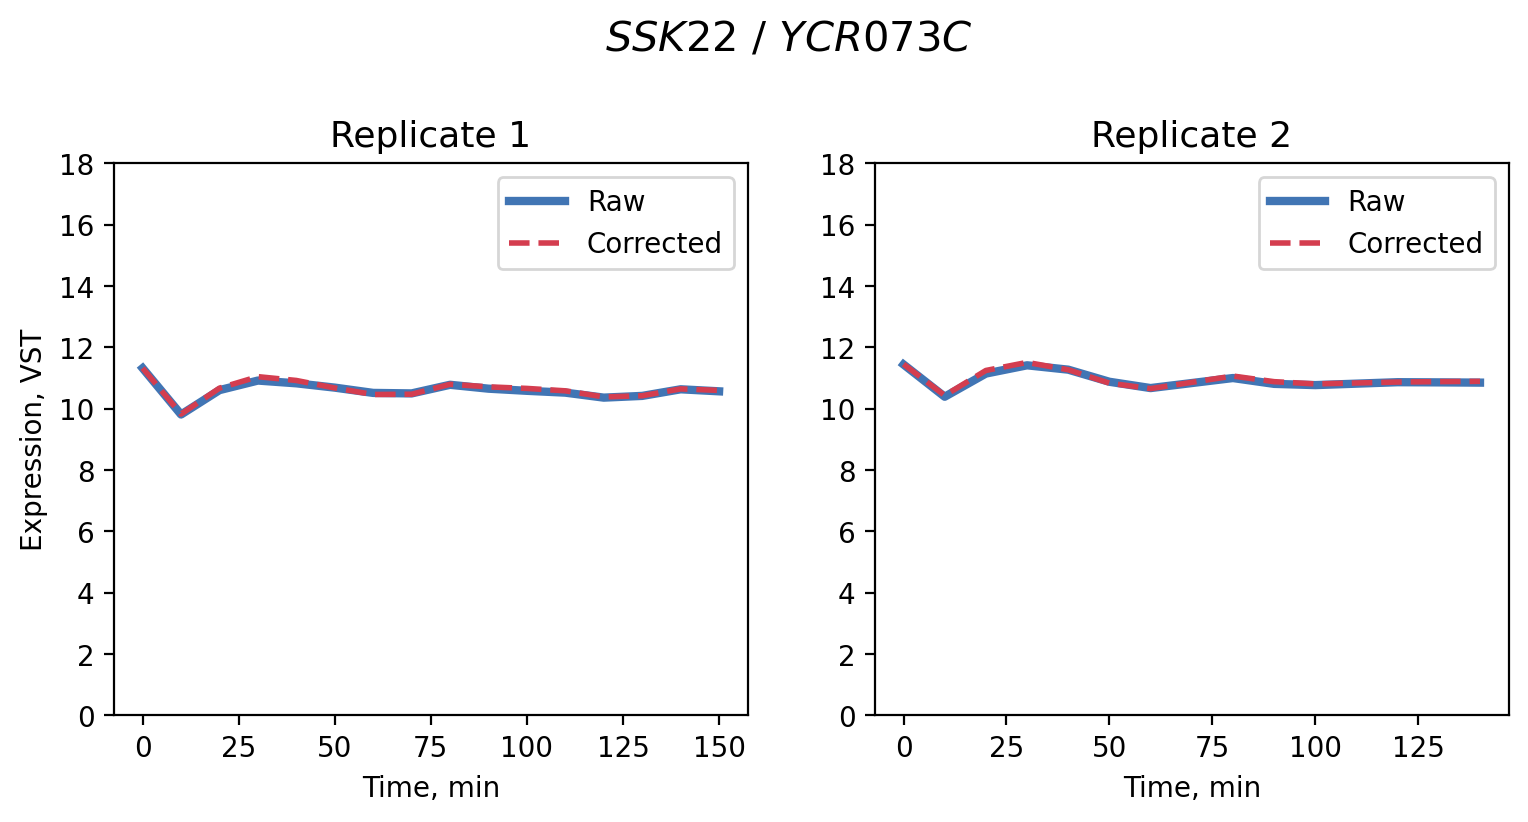

In [672]:
figures.plot_ge_examples(save_dir='output/figures/Copy_Correction/')